In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF

In [12]:
df=pd.read_csv("corpus_zola_paquets_lemm.csv") # Chargement du DataFrame nettoyé à partir du fichier CSV

In [13]:
df.head()

,nom_fichier,id_paquet,phrases_paquet,phrases_lemm
0,1893_20_Le_docteur_Pascal._clean.txt,0,Dans la chaleur de l’ardente après-midi de jui...,chaleur ardent après-midi juillet salle volet ...
1,1893_20_Le_docteur_Pascal._clean.txt,1,"Mais il dut prendre une chaise, la planche du ...",chaise planche haut haut grand taille planche ...
2,1893_20_Le_docteur_Pascal._clean.txt,2,"Oh! Monsieur, la religion n’a jamais fait de m...",monsieur religion mal idée sûr silence diverge...
3,1893_20_Le_docteur_Pascal._clean.txt,3,"De face, dans son visage séché, ses yeux garda...",face visage oeil flamme joli sourir grand-mère...
4,1893_20_Le_docteur_Pascal._clean.txt,4,s’écria la jeune fille. Mais elle était lancée...,jeune fille bon femme fond faubourg pile mort ...


In [14]:
vectorizer = TfidfVectorizer( 
    min_df=3,
    max_df=0.8
    )
# min_df=5 : Ignorer les termes qui apparaissent dans moins de 3 segments, car ils sont considérés comme peu informatifs.
# max_df=0.8 : Ignorer les termes qui apparaissent dans plus de 80% des segments, car ils sont trop fréquents et ne contribuent pas à différencier les segments.

X = vectorizer.fit_transform(df["phrases_lemm"])  
#Appliquer le TF-IDF vectorizer sur les segments de texte nettoyés pour obtenir une matrice de caractéristiques (termes pondérés par leur importance dans les segments).

X.shape

(5327, 11647)

/Users/morganr/analyse_topic_zola/.venv/lib/python3.12/site-packages/sklearn/decomposition/_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 500 reached. Increase it to improve convergence.
  warnings.warn(
/Users/morganr/analyse_topic_zola/.venv/lib/python3.12/site-packages/sklearn/decomposition/_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 500 reached. Increase it to improve convergence.
  warnings.warn(


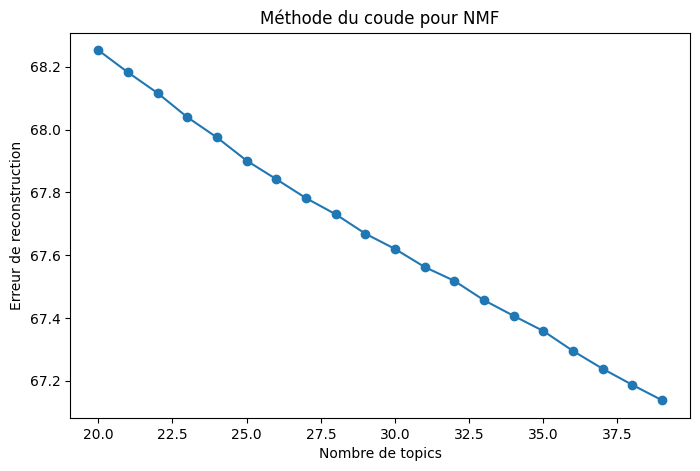

In [9]:
errors = []
k_values = range(20, 40)

for k in k_values:
    nmf = NMF(
        n_components=k,
        random_state=42,
        init="nndsvda",
        max_iter=500
    )
    
    nmf.fit(X)
    errors.append(nmf.reconstruction_err_)

plt.figure(figsize=(8, 5))
plt.plot(k_values, errors, marker="o")
plt.xlabel("Nombre de topics")
plt.ylabel("Erreur de reconstruction")
plt.title("Méthode du coude pour NMF")
plt.show()

In [17]:
def afficher_topics(model, feature_names, n_top_words=10):
    for topic_idx, topic in enumerate(model.components_):
        top_words = [feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]
        print(f"Topic {topic_idx+1} : {' | '.join(top_words)}")



feature_names = vectorizer.get_feature_names_out()

#for k in  [8, 10, 12, 15, 18 ]: # On teste différents nombres de topics (de 5 à 15) pour trouver le nombre optimal de topics pour notre analyse.
    
    #print(f"\n NMF avec {k} topics") 
nmf = NMF(n_components=36, 
          random_state=42,
          init="nndsvda",
          solver="cd",
          max_iter=1000,
          
            )
W = nmf.fit_transform(X)
afficher_topics(nmf, feature_names)

print("Erreur :", nmf.reconstruction_err_)

Topic 1 : femme | mari | homme | jeune | amant | mariage | chose | plaisir | cher | maîtresse
Topic 2 : travail | peuple | vie | bonheur | œuvre | ouvrier | justice | usine | humanité | cité
Topic 3 : arbre | soleil | eau | herbe | ciel | jardin | feuille | ombre | branche | horizon
Topic 4 : million | bourse | cours | action | universelle | banque | affaire | agent | hausse | titre
Topic 5 : abbé | prêtre | curé | jardin | trouche | sous | soutane | préfecture | vicaire | évêque
Topic 6 : père | fils | famille | vieux | fille | mort | année | mariage | parent | ancien
Topic 7 : prussien | soldat | armée | général | route | canon | corps | capitaine | homme | obu
Topic 8 : franc | argent | somme | billet | sou | mois | chiffre | pièce | fortune | rente
Topic 9 : monsieur | dame | porte | vou | air | voix | bon | tante | mot | main
Topic 10 : rue | maison | quartier | trottoir | boutique | place | ville | boulevard | voiture | chaussée
Topic 11 : main | bras | oeil | tête | lèvre | cou 